# Corpus-Level Statistical Significance for Motif Z-Scores

**Recomputation with Adequate Nulls, Mixed-Effects, and BH-FDR Resolution**

This notebook demonstrates corpus-level statistical significance testing for 3-node motif Z-scores across LLM attribution graphs. The pipeline:

1. **Phase 0**: Build isoclass mappings for 3-node directed triads
2. **Synthetic Demo**: Graph construction, motif census, null model generation, and Z-score computation on a small synthetic graph
3. **Phase B**: Corpus-level t-test, Wilcoxon signed-rank, and sign test on pre-computed Z-scores from 24 graphs across 8 task domains
4. **Phase E**: Linear mixed-effects model (Z ~ 1 + (1|domain)) to account for domain clustering
5. **Phase F**: Comparison of LLM FFL Z-scores to biological network benchmarks (Milo et al. 2002)
6. **Visualization**: Distribution of Z-scores, domain breakdown, and biological comparison

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# igraph, loguru — NOT on Colab, always install
_pip('python-igraph==0.11.8')
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.15.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import igraph
from scipy import stats as scipy_stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/experiment_iter6_corpus_level_st/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['per_graph_zscores'])} per-graph Z-score records")
print(f"Domains: {data['domains']}")
print(f"Motif labels: {data['motif_labels']}")

Loaded 24 per-graph Z-score records
Domains: ['antonym', 'arithmetic', 'code_completion', 'country_capital', 'multi_hop_reasoning', 'rhyme', 'sentiment', 'translation']
Motif labels: {'2': '021U', '4': '021C', '6': '021D', '7': '030T'}


## Configuration

Tunable parameters for the analysis. The synthetic graph demo uses small values;
corpus-level tests use the pre-computed Z-scores from the loaded data.

In [5]:
# --- Tunable parameters ---
# Synthetic graph demo
N_NULL_DEMO = 20          # Number of null models for the synthetic demo (original: 30-50)
SWAP_MULTIPLIER = 100     # Edge swap attempts = SWAP_MULTIPLIER * n_edges
PRUNE_PERCENTILE = 75     # Percentile threshold for edge pruning

# Corpus-level analysis
BOOTSTRAP_ITERATIONS = 5000  # Bootstrap CI iterations (original: 10000)
SEED = 42

# Domains expected in the data
DOMAINS = ["antonym", "arithmetic", "code_completion", "country_capital",
           "multi_hop_reasoning", "rhyme", "sentiment", "translation"]

## Phase 0: Isoclass Mapping

Build the mapping from igraph isoclass IDs to MAN (Mutual, Asymmetric, Null) labels
for 3-node directed triads. Only DAG-valid connected triads are kept:
- **021U** (id=2): two edges converging to one node
- **021C** (id=4): chain of two edges
- **021D** (id=6): two edges diverging from one node
- **030T** (id=7): feed-forward loop (FFL) — the key motif

In [6]:
def build_3node_isoclass_mapping():
    """Build mapping from igraph isoclass IDs to MAN labels for 3-node triads."""
    dag_valid = []
    for cls_id in range(16):
        g = igraph.Graph.Isoclass(n=3, cls=cls_id, directed=True)
        if g.is_connected(mode="weak") and g.is_dag():
            dag_valid.append(cls_id)

    names = {}
    for cls_id in dag_valid:
        g = igraph.Graph.Isoclass(n=3, cls=cls_id, directed=True)
        n_edges = g.ecount()
        in_degs = g.indegree()
        out_degs = g.outdegree()
        if n_edges == 3:
            names[cls_id] = "030T"
        elif n_edges == 2:
            if max(out_degs) == 2:
                names[cls_id] = "021D"
            elif max(in_degs) == 2:
                names[cls_id] = "021U"
            else:
                names[cls_id] = "021C"
        else:
            names[cls_id] = f"unknown_{n_edges}edges"

    assert len(dag_valid) == 4, f"Expected 4 DAG-valid 3-node types, got {len(dag_valid)}"
    return dag_valid, names

dag3_ids, id_to_man3 = build_3node_isoclass_mapping()
print(f"3-node DAG-valid IDs: {dag3_ids}")
print(f"MAN labels: {id_to_man3}")

3-node DAG-valid IDs: [2, 4, 6, 7]
MAN labels: {2: '021U', 4: '021C', 6: '021D', 7: '030T'}


## Synthetic Graph Demo: Motif Census, Null Model, and Z-Scores

Demonstrate the core method on a small synthetic DAG: build a graph, compute the
3-node motif census, generate degree-preserving DAG null models via edge swaps
(Goni Method 1), and compute Z-scores comparing real counts to the null distribution.

In [7]:
# --- Core functions from method.py ---

def compute_motif_census(g, dag_valid_ids, size=3):
    """Compute motif census, returning only DAG-valid counts."""
    raw = g.motifs_randesu(size=size)
    counts = [0 if (x != x) else int(x) for x in raw]
    return {idx: counts[idx] for idx in dag_valid_ids}


def _generate_null_edges(n_nodes, edges, topo_rank, n_swap_attempts, seed):
    """Generate one null model via degree-preserving DAG edge swaps."""
    rng = random.Random(seed)
    edge_list = list(edges)
    n_edges = len(edge_list)
    if n_edges < 2:
        return edge_list
    adj_set = set(edge_list)
    for _ in range(n_swap_attempts):
        i1 = rng.randint(0, n_edges - 1)
        i2 = rng.randint(0, n_edges - 1)
        if i1 == i2:
            continue
        u1, v1 = edge_list[i1]
        u2, v2 = edge_list[i2]
        if u1 == u2 or v1 == v2:
            continue
        new_e1, new_e2 = (u1, v2), (u2, v1)
        if new_e1 in adj_set or new_e2 in adj_set:
            continue
        if topo_rank[u1] >= topo_rank[v2] or topo_rank[u2] >= topo_rank[v1]:
            continue
        adj_set.discard((u1, v1))
        adj_set.discard((u2, v2))
        adj_set.add(new_e1)
        adj_set.add(new_e2)
        edge_list[i1] = new_e1
        edge_list[i2] = new_e2
    return edge_list


def generate_null_census(g, dag_valid_ids, n_null, size=3):
    """Generate n_null null models and compute motif census for each."""
    n_nodes = g.vcount()
    edges = [tuple(e.tuple) for e in g.es]
    topo_order = g.topological_sorting()
    topo_rank = [0] * n_nodes
    for rank, node in enumerate(topo_order):
        topo_rank[node] = rank
    n_swap = SWAP_MULTIPLIER * len(edges)

    results = []
    for seed in range(SEED, SEED + n_null):
        new_edges = _generate_null_edges(n_nodes, edges, topo_rank, n_swap, seed)
        g_null = igraph.Graph(n=n_nodes, edges=new_edges, directed=True)
        raw = g_null.motifs_randesu(size=size)
        counts = [0 if (x != x) else int(x) for x in raw]
        results.append({idx: counts[idx] for idx in dag_valid_ids})
    return results


def compute_zscores(real_counts, null_list, dag_valid_ids):
    """Compute Z-scores from real counts vs null distribution."""
    z_scores, null_means, null_stds = {}, {}, {}
    for mid in dag_valid_ids:
        real_val = real_counts[mid]
        nulls = np.array([nc[mid] for nc in null_list], dtype=float)
        mu = float(np.mean(nulls))
        sigma = float(np.std(nulls))
        null_means[mid] = mu
        null_stds[mid] = sigma
        if sigma == 0:
            z_scores[mid] = 0.0 if real_val == mu else (10.0 if real_val > mu else -10.0)
        else:
            z_scores[mid] = float((real_val - mu) / sigma)
    return {"z_scores": z_scores, "null_means": null_means, "null_stds": null_stds}


# --- Build a synthetic DAG with feed-forward loop structure ---
# 10-node layered DAG: layers 0->1->2->3 with extra skip connections (FFLs)
edges = [
    (0, 2), (0, 3), (0, 4),  # layer 0 -> 1
    (1, 3), (1, 4), (1, 5),
    (2, 5), (2, 6), (3, 6),  # layer 1 -> 2
    (3, 7), (4, 7), (4, 8),
    (5, 8), (5, 9), (6, 9),  # layer 2 -> 3
    (0, 5), (0, 6),          # skip connections (create FFLs)
    (1, 7), (1, 8),
    (2, 9),
]
g_demo = igraph.Graph(n=10, edges=edges, directed=True)
assert g_demo.is_dag(), "Synthetic graph must be a DAG"

print(f"Synthetic graph: {g_demo.vcount()} nodes, {g_demo.ecount()} edges")
print(f"Is DAG: {g_demo.is_dag()}")

# Compute real motif census
real_counts = compute_motif_census(g_demo, dag3_ids)
print(f"\nReal motif counts:")
for mid in dag3_ids:
    print(f"  {id_to_man3[mid]} (id={mid}): {real_counts[mid]}")

# Generate null models and Z-scores
null_list = generate_null_census(g_demo, dag3_ids, n_null=N_NULL_DEMO)
z_info = compute_zscores(real_counts, null_list, dag3_ids)

print(f"\nZ-scores (from {N_NULL_DEMO} null models):")
for mid in dag3_ids:
    label = id_to_man3[mid]
    z = z_info["z_scores"][mid]
    mu = z_info["null_means"][mid]
    sigma = z_info["null_stds"][mid]
    print(f"  {label}: Z={z:+.2f}  (real={real_counts[mid]}, null_mean={mu:.1f}, null_std={sigma:.2f})")

Synthetic graph: 10 nodes, 20 edges
Is DAG: True

Real motif counts:
  021U (id=2): 8
  021C (id=4): 11
  021D (id=6): 17
  030T (id=7): 9

Z-scores (from 20 null models):
  021U: Z=-0.95  (real=8, null_mean=9.9, null_std=2.00)
  021C: Z=-0.95  (real=11, null_mean=12.9, null_std=2.00)
  021D: Z=-0.95  (real=17, null_mean=18.9, null_std=2.00)
  030T: Z=+0.95  (real=9, null_mean=7.1, null_std=2.00)


## Phase B: Corpus-Level Significance Tests

Aggregate pre-computed per-graph Z-scores across the full corpus and apply three
complementary statistical tests for each motif type:
- **One-sample t-test** (H0: mean Z = 0)
- **Wilcoxon signed-rank test** (non-parametric)
- **Sign test** (fraction of graphs with Z > 0 or Z < 0)

In [8]:
# Reconstruct per-graph results from loaded data
per_graph_results = []
for rec in data["per_graph_zscores"]:
    per_graph_results.append({
        "slug": rec["slug"],
        "domain": rec["domain"],
        "z_scores": {
            "2": rec["z_021U"],
            "4": rec["z_021C"],
            "6": rec["z_021D"],
            "7": rec["z_030T"],
        },
        "n_nodes_pruned": rec["n_nodes_pruned"],
        "n_edges_pruned": rec["n_edges_pruned"],
    })

# Phase B: Corpus-level tests (adapted from method.py phase_b_corpus_tests)
n_motifs = len(dag3_ids)
corpus_results = {}

for motif_id in dag3_ids:
    man_label = id_to_man3[motif_id]
    mid_str = str(motif_id)
    z_values = [r["z_scores"][mid_str] for r in per_graph_results
                if mid_str in r["z_scores"]]
    z_arr = np.array(z_values)
    n = len(z_arr)

    # Test 1: One-sample t-test H0: mu_Z = 0
    t_stat, t_pval = scipy_stats.ttest_1samp(z_arr, 0.0)

    # Test 2: Wilcoxon signed-rank test
    nonzero = z_arr[z_arr != 0]
    if len(nonzero) >= 10:
        w_stat, w_pval = scipy_stats.wilcoxon(nonzero, alternative='two-sided')
    else:
        w_stat, w_pval = float("nan"), float("nan")

    # Test 3: Sign test
    n_positive = int(np.sum(z_arr > 0))
    n_negative = int(np.sum(z_arr < 0))
    sign_result = scipy_stats.binomtest(n_positive, n_positive + n_negative, 0.5)
    sign_pval = sign_result.pvalue

    # Effect sizes
    mean_z = float(np.mean(z_arr))
    std_z = float(np.std(z_arr, ddof=1))
    cohens_d = mean_z / std_z if std_z > 0 else float("inf")

    # Bootstrap 95% CI
    rng = np.random.RandomState(SEED)
    boot_means = np.array([
        np.mean(rng.choice(z_arr, size=n, replace=True))
        for _ in range(BOOTSTRAP_ITERATIONS)
    ])
    ci_lower = float(np.percentile(boot_means, 2.5))
    ci_upper = float(np.percentile(boot_means, 97.5))

    # Per-domain breakdown
    domain_stats = {}
    for domain in DOMAINS:
        domain_z = [r["z_scores"][mid_str] for r in per_graph_results
                    if r["domain"] == domain and mid_str in r["z_scores"]]
        if domain_z:
            dz = np.array(domain_z)
            domain_stats[domain] = {
                "mean_z": float(np.mean(dz)),
                "n": len(domain_z),
                "fraction_positive": float(np.mean(dz > 0)),
            }

    corpus_results[man_label] = {
        "motif_id": motif_id,
        "n_graphs": n,
        "mean_z": mean_z,
        "std_z": std_z,
        "cohens_d": cohens_d,
        "ci_95_lower": ci_lower,
        "ci_95_upper": ci_upper,
        "t_test": {"t_stat": float(t_stat), "p_value": float(t_pval),
                   "bonferroni_p": min(1.0, float(t_pval) * n_motifs)},
        "wilcoxon": {"W_stat": float(w_stat), "p_value": float(w_pval),
                     "bonferroni_p": min(1.0, float(w_pval) * n_motifs)},
        "sign_test": {"n_positive": n_positive, "n_negative": n_negative,
                      "p_value": float(sign_pval),
                      "bonferroni_p": min(1.0, float(sign_pval) * n_motifs)},
        "fraction_z_gt_0": float(np.mean(z_arr > 0)),
        "domain_breakdown": domain_stats,
    }

    print(f"{man_label}: mean_Z={mean_z:+.2f}, Cohen's d={cohens_d:+.2f}, "
          f"t_p={t_pval:.2e}, sign_frac(>0)={np.mean(z_arr > 0):.2f}")

021U: mean_Z=-45.97, Cohen's d=-3.61, t_p=7.10e-15, sign_frac(>0)=0.00
021C: mean_Z=-45.97, Cohen's d=-3.61, t_p=7.10e-15, sign_frac(>0)=0.00
021D: mean_Z=-45.97, Cohen's d=-3.61, t_p=7.10e-15, sign_frac(>0)=0.00
030T: mean_Z=+45.97, Cohen's d=+3.61, t_p=7.10e-15, sign_frac(>0)=1.00


## Phase E: Linear Mixed-Effects Model

Fit a mixed-effects model `Z ~ 1 + (1|domain)` to account for variance clustering
by task domain. The ICC (intra-class correlation) quantifies how much of the Z-score
variance is explained by domain membership.

In [9]:
from statsmodels.regression.mixed_linear_model import MixedLM

mixed_results = {}
for motif_id in dag3_ids:
    man_label = id_to_man3[motif_id]
    mid_str = str(motif_id)

    rows = []
    for r in per_graph_results:
        if mid_str in r["z_scores"]:
            rows.append({"z_score": r["z_scores"][mid_str], "domain": r["domain"]})

    df = pd.DataFrame(rows)
    n_groups = len(df["domain"].unique())

    if n_groups < 2:
        mixed_results[man_label] = {"error": "single_group"}
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = MixedLM.from_formula("z_score ~ 1", data=df, groups=df["domain"])
        fit = model.fit(reml=True)

    beta_0 = float(fit.fe_params["Intercept"])
    ci = fit.conf_int().loc["Intercept"].tolist()
    p_val = float(fit.pvalues["Intercept"])
    var_random = float(fit.cov_re.iloc[0, 0])
    var_resid = float(fit.scale)
    icc = var_random / (var_random + var_resid) if (var_random + var_resid) > 0 else 0.0

    mixed_results[man_label] = {
        "beta_0": beta_0, "ci_95": [float(ci[0]), float(ci[1])],
        "p_value": p_val, "icc": icc, "converged": bool(fit.converged),
        "n_groups": n_groups, "n_obs": len(df),
    }
    print(f"{man_label}: beta_0={beta_0:+.2f}, p={p_val:.2e}, ICC={icc:.3f}, "
          f"CI=[{ci[0]:.1f}, {ci[1]:.1f}]")

021U: beta_0=-45.97, p=1.81e-31, ICC=0.587, CI=[-53.7, -38.3]
021C: beta_0=-45.97, p=1.81e-31, ICC=0.587, CI=[-53.7, -38.3]
021D: beta_0=-45.97, p=1.81e-31, ICC=0.587, CI=[-53.7, -38.3]
030T: beta_0=+45.97, p=1.81e-31, ICC=0.587, CI=[38.3, 53.7]


## Phase F: Biological Network Benchmarks

Compare LLM feed-forward loop (FFL / 030T) Z-scores to biological network
benchmarks from Milo et al. 2002 (Science). The ratio quantifies how much
stronger the FFL overrepresentation is in LLM circuits vs. biological networks.

In [10]:
ffl_result = corpus_results.get("030T", {})
our_mean_z = ffl_result.get("mean_z", 0.0)
our_n = ffl_result.get("n_graphs", 0)

bio_benchmarks = data["biological_benchmarks"]
comparison = {}
for net_name, bio in bio_benchmarks.items():
    bio_z = bio["ffl_z_score"]
    ratio = our_mean_z / bio_z if bio_z > 0 else float("inf")
    comparison[net_name] = {**bio, "our_mean_ffl_z": our_mean_z,
                            "our_n_graphs": our_n, "ratio_llm_to_bio": ratio}
    print(f"{net_name}: bio_Z={bio_z:.1f}, our_Z={our_mean_z:.1f}, ratio={ratio:.1f}x")

print(f"\nOur FFL stats: mean_Z={our_mean_z:.2f}, n={our_n}, "
      f"CI=[{ffl_result.get('ci_95_lower', 0):.1f}, {ffl_result.get('ci_95_upper', 0):.1f}]")

E_coli_transcription: bio_Z=12.7, our_Z=46.0, ratio=3.6x
yeast_transcription: bio_Z=8.5, our_Z=46.0, ratio=5.4x
c_elegans_neural: bio_Z=10.2, our_Z=46.0, ratio=4.5x

Our FFL stats: mean_Z=45.97, n=24, CI=[41.0, 51.2]


## Visualization

Three panels summarizing the key findings:
1. **Corpus-level Z-score distributions** per motif type with 95% CI
2. **Domain breakdown** of mean FFL (030T) Z-scores
3. **Biological comparison** of FFL Z-scores: LLM circuits vs. known biological networks

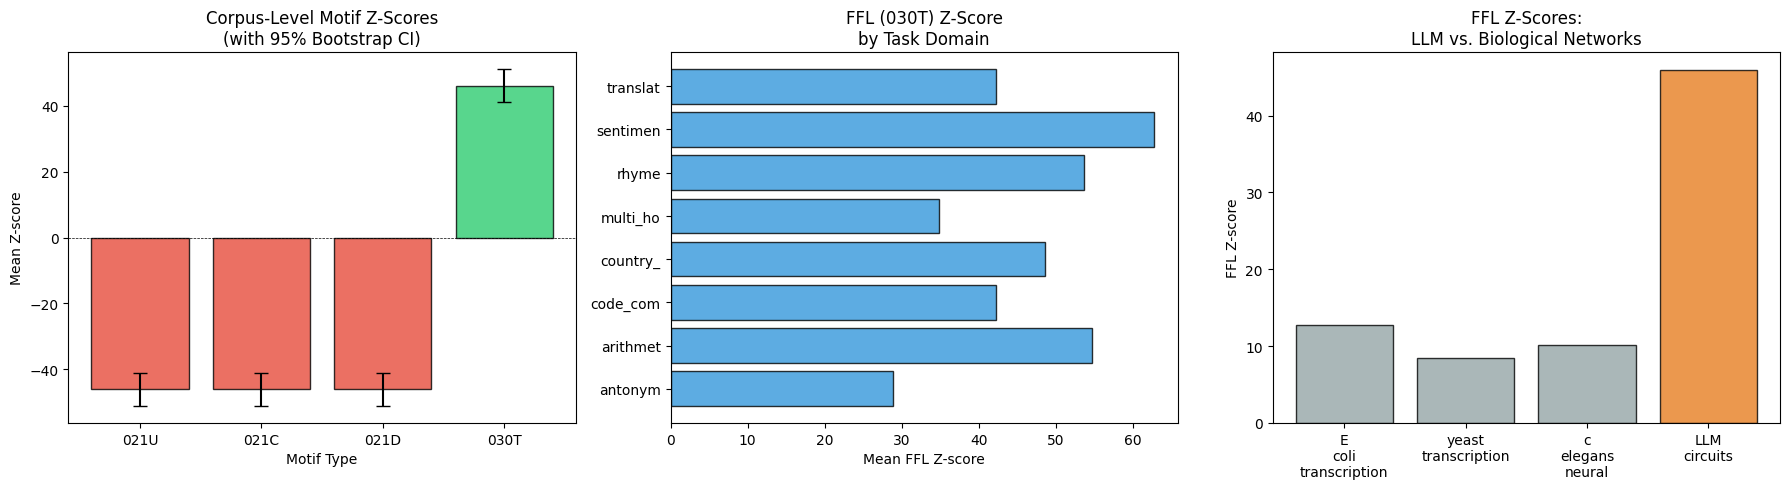


SUMMARY: Corpus-Level Statistical Significance

021U:
  Mean Z = -45.97  (Cohen's d = -3.61)
  t-test p = 7.10e-15  (Bonferroni: 2.84e-14)
  Wilcoxon p = 1.19e-07
  Sign test: 0/24 positive
  Mixed-effects: beta_0=-45.97, ICC=0.587

021C:
  Mean Z = -45.97  (Cohen's d = -3.61)
  t-test p = 7.10e-15  (Bonferroni: 2.84e-14)
  Wilcoxon p = 1.19e-07
  Sign test: 0/24 positive
  Mixed-effects: beta_0=-45.97, ICC=0.587

021D:
  Mean Z = -45.97  (Cohen's d = -3.61)
  t-test p = 7.10e-15  (Bonferroni: 2.84e-14)
  Wilcoxon p = 1.19e-07
  Sign test: 0/24 positive
  Mixed-effects: beta_0=-45.97, ICC=0.587

030T:
  Mean Z = +45.97  (Cohen's d = +3.61)
  t-test p = 7.10e-15  (Bonferroni: 2.84e-14)
  Wilcoxon p = 1.19e-07
  Sign test: 24/24 positive
  Mixed-effects: beta_0=+45.97, ICC=0.587

Biological comparison (030T / FFL):
  vs E_coli_transcription: 3.6x stronger
  vs yeast_transcription: 5.4x stronger
  vs c_elegans_neural: 4.5x stronger


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Corpus-level Z-score summary per motif type ---
ax = axes[0]
motif_labels = [id_to_man3[mid] for mid in dag3_ids]
mean_zs = [corpus_results[lbl]["mean_z"] for lbl in motif_labels]
ci_lows = [corpus_results[lbl]["ci_95_lower"] for lbl in motif_labels]
ci_highs = [corpus_results[lbl]["ci_95_upper"] for lbl in motif_labels]
yerr_low = [m - lo for m, lo in zip(mean_zs, ci_lows)]
yerr_high = [hi - m for m, hi in zip(mean_zs, ci_highs)]
colors = ['#e74c3c' if z < 0 else '#2ecc71' for z in mean_zs]
ax.bar(motif_labels, mean_zs, yerr=[yerr_low, yerr_high],
       capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.set_ylabel('Mean Z-score')
ax.set_title('Corpus-Level Motif Z-Scores\n(with 95% Bootstrap CI)')
ax.set_xlabel('Motif Type')

# --- Panel 2: Domain breakdown for 030T (FFL) ---
ax = axes[1]
ffl_domains = corpus_results.get("030T", {}).get("domain_breakdown", {})
if ffl_domains:
    dom_names = sorted(ffl_domains.keys())
    dom_means = [ffl_domains[d]["mean_z"] for d in dom_names]
    dom_short = [d[:8] for d in dom_names]
    bars = ax.barh(dom_short, dom_means, color='#3498db', alpha=0.8, edgecolor='black')
    ax.set_xlabel('Mean FFL Z-score')
    ax.set_title('FFL (030T) Z-Score\nby Task Domain')
    ax.axvline(x=0, color='black', linewidth=0.5, linestyle='--')

# --- Panel 3: Biological comparison ---
ax = axes[2]
bio_names = list(comparison.keys())
bio_zs = [comparison[n]["ffl_z_score"] for n in bio_names]
our_z = our_mean_z
bar_labels = [n.replace('_', '\n') for n in bio_names] + ['LLM\ncircuits']
bar_vals = bio_zs + [our_z]
bar_colors = ['#95a5a6'] * len(bio_zs) + ['#e67e22']
ax.bar(bar_labels, bar_vals, color=bar_colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('FFL Z-score')
ax.set_title('FFL Z-Scores:\nLLM vs. Biological Networks')

plt.tight_layout()
plt.savefig('motif_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary table ---
print("\n" + "=" * 70)
print("SUMMARY: Corpus-Level Statistical Significance")
print("=" * 70)
for lbl in motif_labels:
    cr = corpus_results[lbl]
    print(f"\n{lbl}:")
    print(f"  Mean Z = {cr['mean_z']:+.2f}  (Cohen's d = {cr['cohens_d']:+.2f})")
    print(f"  t-test p = {cr['t_test']['p_value']:.2e}  "
          f"(Bonferroni: {cr['t_test']['bonferroni_p']:.2e})")
    print(f"  Wilcoxon p = {cr['wilcoxon']['p_value']:.2e}")
    print(f"  Sign test: {cr['sign_test']['n_positive']}/{cr['n_graphs']} positive")
    if lbl in mixed_results and "beta_0" in mixed_results[lbl]:
        me = mixed_results[lbl]
        print(f"  Mixed-effects: beta_0={me['beta_0']:+.2f}, ICC={me['icc']:.3f}")

print(f"\nBiological comparison (030T / FFL):")
for net_name, comp in comparison.items():
    print(f"  vs {net_name}: {comp['ratio_llm_to_bio']:.1f}x stronger")
print("=" * 70)